## Simple Steam prices prediction
* [Dataset](https://www.kaggle.com/datasets/artyomkruglov/gaming-profiles-2025-steam-playstation-xbox):  archive/steam/\[ games.csv, prices.csv \] -> ./dataset/\[ games.csv, prices.csv \]

In [1]:
from ast import literal_eval

from tqdm.notebook import tqdm

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [2]:
# df = pd.DataFrame({'price': [10, 12, 15, 18, 20]})

# df['lag_1_price'] = df['price'].shift(1)
# df['lag_2_price'] = df['price'].shift(2)

# df['lag_1_price_2'] = df['lag_1_price'].fillna(df['price'].iloc[0])
# df['lag_2_price_2'] = df['lag_2_price'].fillna(df['price'].iloc[0])

# df['rolling_default'] = df['price'].rolling(3, min_periods=1).mean()

# df['rolling_left'] = df['price'].rolling(3, min_periods=1, closed='left').mean()
# df['rolling_left_2'] = df['rolling_left'].fillna(df['price'].iloc[0])

# df

### Settings

In [3]:
available_currencies = ["usd", "eur", "gbp", "jpy", "rub"]
picked_cur = available_currencies[0]
max_price = 100

picked_cur, max_price

('usd', 100)

### Dataset work

In [7]:
games = pd.read_csv("./dataset/games.csv")
prices = pd.read_csv("./dataset/prices.csv")

In [84]:
print(len(prices))
prices.sample(n=10)

4414273


,gameid,usd,eur,gbp,jpy,rub,date_acquired
1985093,2983840,1.99,1.99,1.69,235.0,82.0,2025-01-07
1058577,374830,4.99,NaN,3.99,520.0,133.0,2024-12-18
3360680,2829170,NaN,NaN,NaN,NaN,NaN,2025-02-04
4182228,1466170,11.99,9.99,9.29,1220.0,289.0,2025-02-20
3058013,2006940,NaN,NaN,NaN,NaN,NaN,2025-01-29
1052374,512770,0.99,0.99,0.89,120.0,42.0,2024-12-18
3879994,2461150,14.99,13.99,11.99,1480.0,1149.0,2025-02-14
4398147,347690,9.99,9.75,8.50,1200.0,385.0,2025-02-24
666878,625980,19.99,19.99,14.99,2000.0,710.0,2024-12-10
3661719,687730,NaN,NaN,NaN,NaN,NaN,2025-02-10


In [85]:
print(len(games))
games.head(10)

98248


,gameid,title,developers,publishers,genres,supported_languages,release_date
0,3281560,Horror Game To Play With Friends! Playtest,NaN,NaN,NaN,NaN,2024-10-21
1,3280930,Eternals' Path Playtest,NaN,NaN,NaN,NaN,2024-10-17
2,3280770,ANGST: A TALE OF SURVIVAL - Singleplayer Playtest,NaN,NaN,NaN,NaN,2024-10-13
3,3279790,Montabi Playtest,NaN,NaN,NaN,NaN,2024-10-13
4,3278320,파이팅걸 유리 Playtest,NaN,NaN,NaN,NaN,2024-10-12
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",2024-10-11
6,3277430,Objective: F.E.A.S.T. Playtest,NaN,NaN,NaN,NaN,2024-10-12
7,3276500,Fortune Avenue Playtest,NaN,NaN,NaN,NaN,2024-10-09
8,3274370,Beyond the Ordinary Playtest,NaN,NaN,NaN,NaN,2024-10-11
9,3274670,Quantum Joe Playtest,NaN,NaN,NaN,NaN,2024-10-11


In [9]:
merged = pd.merge(games, prices, on=['gameid'], how='inner')

In [10]:
merged = merged.dropna(subset=['release_date', picked_cur])

In [11]:
merged.title.str.lower().str.contains("playtest").any()

False

In [12]:
merged = merged[merged[picked_cur] <= max_price]

In [13]:
merged['release_date'] = pd.to_datetime(merged['release_date'], errors='coerce')
merged['date_acquired'] = pd.to_datetime(merged['date_acquired'], errors='coerce')

In [14]:
merged = merged.sort_values(['release_date', 'date_acquired']).reset_index(drop=True)

In [15]:
print(merged.size)
merged.head()

45412406


,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,eur,gbp,jpy,rub,date_acquired
0,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,2.49,NaN,1.49,245.0,62.0,2024-11-28
1,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,2.49,NaN,1.49,245.0,62.0,2024-11-30
2,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,2.49,NaN,1.49,245.0,62.0,2024-12-02
3,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,2.49,NaN,1.49,245.0,62.0,2024-12-04
4,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,9.99,NaN,5.99,980.0,249.0,2024-12-06


In [16]:
# merged['genres'] = merged['genres'].fillna("[]").apply(literal_eval)
# merged['developers'] = merged['developers'].fillna("[]").apply(literal_eval)
# merged['publishers'] = merged['publishers'].fillna("[]").apply(literal_eval)

In [17]:
# max_time = merged[['release_date', 'date_acquired']].max().max()

merged['days_since_release'] = (merged['date_acquired'] - merged['release_date']).dt.days

In [18]:
merged.head()

,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,eur,gbp,jpy,rub,date_acquired,days_since_release
0,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,2.49,NaN,1.49,245.0,62.0,2024-11-28,10013
1,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,2.49,NaN,1.49,245.0,62.0,2024-11-30,10015
2,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,2.49,NaN,1.49,245.0,62.0,2024-12-02,10017
3,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,2.49,NaN,1.49,245.0,62.0,2024-12-04,10019
4,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997-06-30,9.99,NaN,5.99,980.0,249.0,2024-12-06,10021


In [19]:
def transform_to_id(df, name) -> tuple[pd.Series, dict, list]:
    s = df[name]

    unique = s.explode().unique()
    vocab = { n: i for i, n in enumerate(unique) }

    s = s.map(lambda x: [vocab[y] for y in x])

    return s, vocab, unique

In [20]:
# genres_id, genres_vocab, _ = transform_to_id(merged, 'genres')

In [21]:
# devs_id, devs_vocab, _ = transform_to_id(merged, 'developers')

In [22]:
# pubs_id, pubs_vocab, _ = transform_to_id(merged, 'publishers')

In [23]:
# merged['genres'] = genres_id
# merged['developers'] = devs_id
# merged['publishers'] = pubs_id

In [24]:
merged['year'] = merged['date_acquired'].dt.year
merged['month'] = merged['date_acquired'].dt.month
merged['dayofweek'] = merged['date_acquired'].dt.dayofweek

In [25]:
merged['release_date'] = merged['release_date'].dt.year

In [26]:
merged['month_sin'] = np.sin(2 * np.pi * merged['month'] / 12)
merged['month_cos'] = np.cos(2 * np.pi * merged['month'] / 12)
merged['dow_sin'] = np.sin(2 * np.pi * merged['dayofweek'] / 7)
merged['dow_cos'] = np.cos(2 * np.pi * merged['dayofweek'] / 7)

In [27]:
merged = merged.drop(set(available_currencies).difference([picked_cur]), axis=1)

In [28]:
merged1 = merged.copy()

In [29]:
merged

,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,date_acquired,days_since_release,year,month,dayofweek,month_sin,month_cos,dow_sin,dow_cos
0,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997,2.49,2024-11-28,10013,2024,11,3,-5.000000e-01,0.866025,0.433884,-0.900969
1,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997,2.49,2024-11-30,10015,2024,11,5,-5.000000e-01,0.866025,-0.974928,-0.222521
2,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997,2.49,2024-12-02,10017,2024,12,0,-2.449294e-16,1.000000,0.000000,1.000000
3,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997,2.49,2024-12-04,10019,2024,12,2,-2.449294e-16,1.000000,0.974928,-0.222521
4,282010,Carmageddon Max Pack,['Stainless Games Ltd'],['THQ Nordic'],"['Action', 'Indie', 'Racing']",['English'],1997,9.99,2024-12-06,10021,2024,12,4,-2.449294e-16,1.000000,-0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493257,3254150,SpyGuys,['Olly'],['OllyGames'],"['Action', 'Indie', 'Strategy']",['English'],2025,2.99,2025-02-24,45,2025,2,0,8.660254e-01,0.500000,0.000000,1.000000
3493258,3395190,Sex Adventures - Incest Family - Episode 1,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2025,4.99,2025-02-24,45,2025,2,0,8.660254e-01,0.500000,0.000000,1.000000
3493259,1144240,MolaMolaAdventure,['Bibi'],['BibiPiece'],"['Action', 'Indie']","['Traditional Chinese', 'English', 'Japanese',...",2025,4.99,2025-02-24,45,2025,2,0,8.660254e-01,0.500000,0.000000,1.000000
3493260,3395080,KINGDOM CUM,['Nicole Dusterly'],['Wet one handed game studio'],"['Adventure', 'Indie']",['English'],2025,5.99,2025-02-24,45,2025,2,0,8.660254e-01,0.500000,0.000000,1.000000


In [30]:
def create_time_features_lag(group):
    group = group.copy()
    earliest = group['usd'].iloc[0]
    
    group['lag_1_price'] = group['usd'].shift(1).fillna(earliest)
    group['lag_2_price'] = group['usd'].shift(2).fillna(earliest)

    group['rolling_mean_3'] = group['usd'].rolling(window=3, min_periods=1, closed='left').mean().fillna(earliest)
    group['rolling_mean_5'] = group['usd'].rolling(window=5, min_periods=1, closed='left').mean().fillna(earliest)
    return group

In [31]:
merged = merged.groupby('gameid').apply(create_time_features_lag)

merged

D:\Users\foler\AppData\Local\Temp\ipykernel_16152\3829453269.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged = merged.groupby('gameid').apply(create_time_features_lag)


gameid              title developers publishers      genres  \
gameid                                                                          
10      180           10     Counter-Strike  ['Valve']  ['Valve']  ['Action']   
        182           10     Counter-Strike  ['Valve']  ['Valve']  ['Action']   
        184           10     Counter-Strike  ['Valve']  ['Valve']  ['Action']   
        186           10     Counter-Strike  ['Valve']  ['Valve']  ['Action']   
        188           10     Counter-Strike  ['Valve']  ['Valve']  ['Action']   
...                  ...                ...        ...        ...         ...   
3418820 3493198  3418820  Platformer Slider     ['me']     ['me']  ['Casual']   
        3493213  3418820  Platformer Slider     ['me']     ['me']  ['Casual']   
        3493227  3418820  Platformer Slider     ['me']     ['me']  ['Casual']   
        3493241  3418820  Platformer Slider     ['me']     ['me']  ['Casual']   
        3493255  3418820  Platformer Slider     ['me']     ['me']  ['Casual']   

                                               supported_languages  \
gameid                                                               
10      180      ['English', 'French', 'German', 'Italian', 'Sp...   
        182      ['English', 'French', 'German', 'Italian', 'Sp...   
        184      ['English', 'French', 'German', 'Italian', 'Sp...   
        186      ['English', 'French', 'German', 'Italian', 'Sp...   
        188      ['English', 'French', 'German', 'Italian', 'Sp...   
...                                                            ...   
3418820 3493198                                        ['English']   
        3493213                                        ['English']   
        3493227                                        ['English']   
        3493241                                        ['English']   
        3493255                                        ['English']   

                 release_date   usd date_acquired  days_since_release  ...  \
gameid                                                                 ...   
10      180              2000  1.99    2024-11-28                8793  ...   
        182              2000  1.99    2024-11-30                8795  ...   
        184              2000  1.99    2024-12-02                8797  ...   
        186              2000  1.99    2024-12-04                8799  ...   
        188              2000  9.99    2024-12-06                8801  ...   
...                       ...   ...           ...                 ...  ...   
3418820 3493198          2025  0.99    2025-02-16                  37  ...   
        3493213          2025  0.99    2025-02-18                  39  ...   
        3493227          2025  0.99    2025-02-20                  41  ...   
        3493241          2025  0.99    2025-02-22                  43  ...   
        3493255          2025  0.99    2025-02-24                  45  ...   

                 month  dayofweek     month_sin  month_cos   dow_sin  \
gameid                                                                 
10      180         11          3 -5.000000e-01   0.866025  0.433884   
        182         11          5 -5.000000e-01   0.866025 -0.974928   
        184         12          0 -2.449294e-16   1.000000  0.000000   
        186         12          2 -2.449294e-16   1.000000  0.974928   
        188         12          4 -2.449294e-16   1.000000 -0.433884   
...                ...        ...           ...        ...       ...   
3418820 3493198      2          6  8.660254e-01   0.500000 -0.781831   
        3493213      2          1  8.660254e-01   0.500000  0.781831   
        3493227      2          3  8.660254e-01   0.500000  0.433884   
        3493241      2          5  8.660254e-01   0.500000 -0.974928   
        3493255      2          0  8.660254e-01   0.500000  0.000000   

                  dow_cos  lag_1_price  lag_2_price  rolling_mean_3  \
gameid                        

In [32]:
merged = merged.dropna().reset_index(drop=True)

merged

,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,date_acquired,days_since_release,...,month,dayofweek,month_sin,month_cos,dow_sin,dow_cos,lag_1_price,lag_2_price,rolling_mean_3,rolling_mean_5
0,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,1.99,2024-11-28,8793,...,11,3,-5.000000e-01,0.866025,0.433884,-0.900969,1.99,1.99,1.99,1.99
1,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,1.99,2024-11-30,8795,...,11,5,-5.000000e-01,0.866025,-0.974928,-0.222521,1.99,1.99,1.99,1.99
2,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,1.99,2024-12-02,8797,...,12,0,-2.449294e-16,1.000000,0.000000,1.000000,1.99,1.99,1.99,1.99
3,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,1.99,2024-12-04,8799,...,12,2,-2.449294e-16,1.000000,0.974928,-0.222521,1.99,1.99,1.99,1.99
4,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,9.99,2024-12-06,8801,...,12,4,-2.449294e-16,1.000000,-0.433884,-0.900969,1.99,1.99,1.99,1.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463171,3418820,Platformer Slider,['me'],['me'],['Casual'],['English'],2025,0.99,2025-02-16,37,...,2,6,8.660254e-01,0.500000,-0.781831,0.623490,0.99,0.99,0.99,0.99
3463172,3418820,Platformer Slider,['me'],['me'],['Casual'],['English'],2025,0.99,2025-02-18,39,...,2,1,8.660254e-01,0.500000,0.781831,0.623490,0.99,0.99,0.99,0.99
3463173,3418820,Platformer Slider,['me'],['me'],['Casual'],['English'],2025,0.99,2025-02-20,41,...,2,3,8.660254e-01,0.500000,0.433884,-0.900969,0.99,0.99,0.99,0.99
3463174,3418820,Platformer Slider,['me'],['me'],['Casual'],['English'],2025,0.99,2025-02-22,43,...,2,5,8.660254e-01,0.500000,-0.974928,-0.222521,0.99,0.99,0.99,0.99


In [33]:
merged2 = merged.copy()

In [34]:
aaa = merged.groupby('gameid').count()['title']

<Axes: >

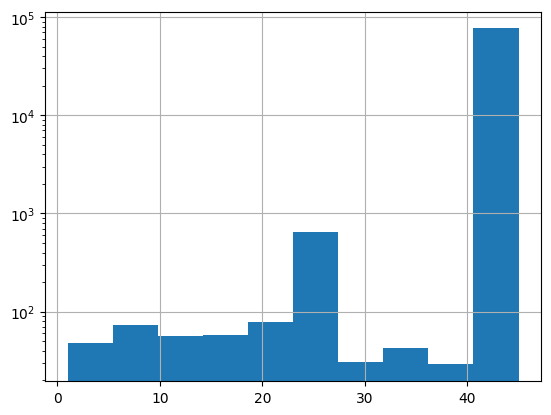

In [35]:
aaa.hist(log=True)

In [36]:
aaa.min()

1

# LightGBM

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

In [38]:
df_final = merged.copy()

In [39]:
enc_dict = {}
categorical_cols = ['title']  # Добавьте сюда все категориальные колонки
for col in categorical_cols:
    le = LabelEncoder()
    df_final[f'{col}_enc'] = le.fit_transform(merged[col])
    enc_dict[col] = le

# Обрабатываем столбцы со списками (глобальный энкодер для каждого)
list_cols = ['developers', 'publishers', 'genres', 'supported_languages']
for col in list_cols:
    # Применяем уникальный LabelEncoder к строковому представлению списка
    le = LabelEncoder()
    df_final[f'{col}_enc'] = le.fit_transform(merged[col].astype(str))
    enc_dict[col] = le

# Удаляем возможные пропуски, которые могли появиться из-за неполных данных
df_final = df_final.dropna()

In [40]:
df_final

,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,date_acquired,days_since_release,...,dow_cos,lag_1_price,lag_2_price,rolling_mean_3,rolling_mean_5,title_enc,developers_enc,publishers_enc,genres_enc,supported_languages_enc
0,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,1.99,2024-11-28,8793,...,-0.900969,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
1,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,1.99,2024-11-30,8795,...,-0.222521,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
2,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,1.99,2024-12-02,8797,...,1.000000,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
3,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,1.99,2024-12-04,8799,...,-0.222521,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
4,10,Counter-Strike,['Valve'],['Valve'],['Action'],"['English', 'French', 'German', 'Italian', 'Sp...",2000,9.99,2024-12-06,8801,...,-0.900969,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463171,3418820,Platformer Slider,['me'],['me'],['Casual'],['English'],2025,0.99,2025-02-16,37,...,0.623490,0.99,0.99,0.99,0.99,47444,44876,39684,1075,12336
3463172,3418820,Platformer Slider,['me'],['me'],['Casual'],['English'],2025,0.99,2025-02-18,39,...,0.623490,0.99,0.99,0.99,0.99,47444,44876,39684,1075,12336
3463173,3418820,Platformer Slider,['me'],['me'],['Casual'],['English'],2025,0.99,2025-02-20,41,...,-0.900969,0.99,0.99,0.99,0.99,47444,44876,39684,1075,12336
3463174,3418820,Platformer Slider,['me'],['me'],['Casual'],['English'],2025,0.99,2025-02-22,43,...,-0.222521,0.99,0.99,0.99,0.99,47444,44876,39684,1075,12336


In [41]:
da = np.sort(merged['date_acquired'].unique())
test_start_date = da[int(len(da)*0.8)]
test_start_date

numpy.datetime64('2025-02-08T00:00:00.000000000')

In [42]:
da

array(['2024-11-28T00:00:00.000000000', '2024-11-30T00:00:00.000000000',
       '2024-12-02T00:00:00.000000000', '2024-12-04T00:00:00.000000000',
       '2024-12-06T00:00:00.000000000', '2024-12-08T00:00:00.000000000',
       '2024-12-10T00:00:00.000000000', '2024-12-12T00:00:00.000000000',
       '2024-12-14T00:00:00.000000000', '2024-12-16T00:00:00.000000000',
       '2024-12-18T00:00:00.000000000', '2024-12-20T00:00:00.000000000',
       '2024-12-22T00:00:00.000000000', '2024-12-24T00:00:00.000000000',
       '2024-12-26T00:00:00.000000000', '2024-12-28T00:00:00.000000000',
       '2024-12-30T00:00:00.000000000', '2025-01-01T00:00:00.000000000',
       '2025-01-03T00:00:00.000000000', '2025-01-05T00:00:00.000000000',
       '2025-01-07T00:00:00.000000000', '2025-01-09T00:00:00.000000000',
       '2025-01-11T00:00:00.000000000', '2025-01-13T00:00:00.000000000',
       '2025-01-15T00:00:00.000000000', '2025-01-17T00:00:00.000000000',
       '2025-01-19T00:00:00.000000000', '2025-01-21

In [43]:
train_mask = merged['date_acquired'] < test_start_date
test_mask = merged['date_acquired'] >= test_start_date

df_train = df_final[train_mask]
df_test = df_final[test_mask]

1 36


<Axes: >

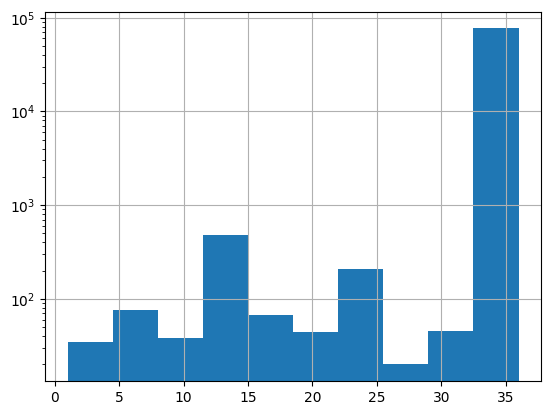

In [44]:
bbb = df_train.groupby('gameid').count()['title']
print(bbb.min(), bbb.max())
bbb.hist(log=True)

1 9


<Axes: >

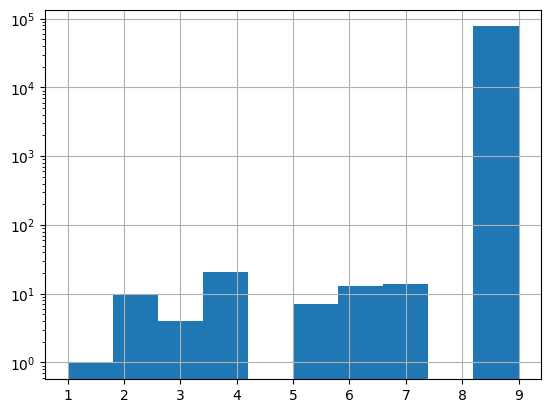

In [45]:
ccc = df_test.groupby('gameid').count()['title']
print(ccc.min(), ccc.max())
ccc.hist(log=True)

In [46]:
# def create_time_features_roll(group):
#     group = group.copy()
#     # Скользящее среднее за 3 и 5 периодов
#     group['rolling_mean_3'] = group['usd'].rolling(window=3, min_periods=1).mean()
#     group['rolling_mean_5'] = group['usd'].rolling(window=5, min_periods=1).mean()
#     return group

In [47]:
# df_train = df_train.groupby('title').apply(create_time_features_roll)
# df_test = df_test.groupby('title').apply(create_time_features_roll)

# df_train = df_train.dropna().reset_index(drop=True)
# df_test = df_test.dropna().reset_index(drop=True)

In [48]:
feature_cols = [
    'developers_enc', 'publishers_enc', 'genres_enc', 
    'supported_languages_enc', 'days_since_release', 

    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    
    'lag_1_price', 'lag_2_price',
    'rolling_mean_3', 'rolling_mean_5',
]

X_train = df_train[feature_cols].copy()
y_train = df_train[picked_cur]

X_test = df_test[feature_cols].copy()
y_test = df_test[picked_cur]

In [49]:
len(df_final), len(X_train) + len(X_test), len(X_train), len(X_test)

(3463176, 3463176, 2770721, 692455)

In [50]:
categorical_features = {f'{col}_enc' for col in categorical_cols + list_cols}
categorical_features.difference_update({'title_enc'})
categorical_features

{'developers_enc', 'genres_enc', 'publishers_enc', 'supported_languages_enc'}

In [170]:
n_est = [*range(0, 101, 10)] #+ [*range(100, 500, 50)]
rmse_train = []
rmse_test = []
for n in n_est:
    print(n, end=" ")
    _lgb_model = lgb.LGBMRegressor(
        random_state=42,
        n_estimators=n or 1,
        force_row_wise=True
    )

    _lgb_model.fit(
        X_train,
        y_train,
        categorical_feature=categorical_features
    )

    y_pred_train = _lgb_model.predict(X_train)
    rmse_train.append(root_mean_squared_error(y_train, y_pred_train))

    y_pred_test = _lgb_model.predict(X_test)
    rmse_test.append(root_mean_squared_error(y_test, y_pred_test))

    

0 [LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 2770721, number of used features: 13
[LightGBM] [Info] Start training from score 7.450706
10 [LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 2770721, number of used features: 13
[LightGBM] [Info] Start training from score 7.450706
20 [LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 2770721, number of used features: 13
[LightGBM] [Info] Start training from score 7.450706
30 [LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 2770721, number of used features: 13
[LightGBM] [Info] Start training from score 7.450706
40 [LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 2770721, number of used features: 13
[LightGBM] [Info] Start training from score 7.450706
50 [LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points

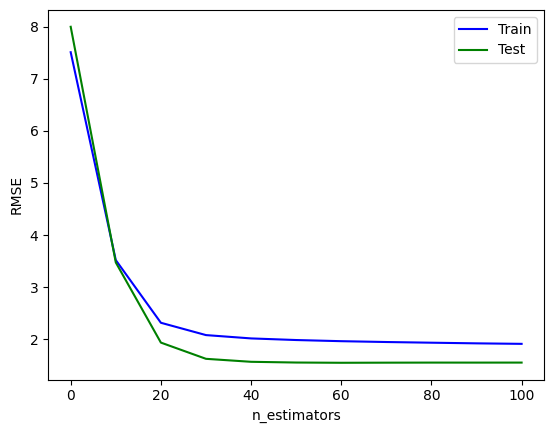

In [171]:
plt.plot(n_est, rmse_train, 'b')
plt.plot(n_est, rmse_test, 'g')
plt.legend(["Train", "Test"])
plt.ylabel("RMSE")
plt.xlabel("n_estimators")
plt.show()

In [51]:
lgb_model = lgb.LGBMRegressor(
    random_state=42,
    n_estimators=100,
    # learning_rate=0.05,
    # max_depth=10
)

In [52]:
lgb_model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_features
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017866 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 2770721, number of used features: 13
[LightGBM] [Info] Start training from score 7.450706


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [53]:
y_pred = lgb_model.predict(X_test)

In [54]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

MAE: 0.39
RMSE: 1.55
R2: 0.97


In [55]:
feature_importances = pd.DataFrame({
    'feature': lgb_model.feature_name_,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importances)

                    feature  importance
9               lag_1_price         773
7                   dow_sin         315
1            publishers_enc         278
12           rolling_mean_5         270
4        days_since_release         252
3   supported_languages_enc         236
2                genres_enc         219
8                   dow_cos         211
11           rolling_mean_3         113
10              lag_2_price          96
5                 month_sin          90
0            developers_enc          78
6                 month_cos          69


In [56]:
y_true = y_test

# Real data

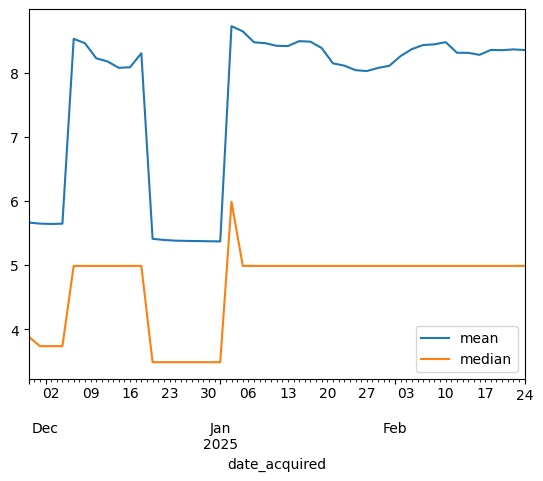

In [250]:
ddd = merged[['usd', 'date_acquired']].groupby('date_acquired')
ax = ddd.mean().plot()
ddd.median().plot(ax=ax)

plt.legend(['mean', 'median'])

In [ ]:
# df_final.drop(columns=['title', 'release_date', 'usd']).select_dtypes(include=[np.number])

,gameid,days_since_release,year,month,dayofweek,month_sin,month_cos,dow_sin,dow_cos,lag_1_price,lag_2_price,rolling_mean_3,rolling_mean_5,title_enc,developers_enc,publishers_enc,genres_enc,supported_languages_enc
0,10,8793,2024,11,3,-5.000000e-01,0.866025,0.433884,-0.900969,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
1,10,8795,2024,11,5,-5.000000e-01,0.866025,-0.974928,-0.222521,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
2,10,8797,2024,12,0,-2.449294e-16,1.000000,0.000000,1.000000,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
3,10,8799,2024,12,2,-2.449294e-16,1.000000,0.974928,-0.222521,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
4,10,8801,2024,12,4,-2.449294e-16,1.000000,-0.433884,-0.900969,1.99,1.99,1.99,1.99,13252,40767,35995,560,432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463171,3418820,37,2025,2,6,8.660254e-01,0.500000,-0.781831,0.623490,0.99,0.99,0.99,0.99,47444,44876,39684,1075,12336
3463172,3418820,39,2025,2,1,8.660254e-01,0.500000,0.781831,0.623490,0.99,0.99,0.99,0.99,47444,44876,39684,1075,12336
3463173,3418820,41,2025,2,3,8.660254e-01,0.500000,0.433884,-0.900969,0.99,0.99,0.99,0.99,47444,44876,39684,1075,12336
3463174,3418820,43,2025,2,5,8.660254e-01,0.500000,-0.974928,-0.222521,0.99,0.99,0.99,0.99,47444,44876,39684,1075,12336


In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt

# # Загрузка предобработанного датасета
# data = df_final.groupby('title').sample(n=1, random_state=42).reset_index(drop=True)

# # Выборка признаков, участвующих в визуализации
# # (например: 'price', 'days_since_release', 'genre_Action', 'genre_RPG', 'publisher_EA' и т.д.)
# X = data.drop(columns=['gameid', 'title_enc', 'release_date', 'lag_1_price', 'lag_2_price', 'rolling_mean_3', 'rolling_mean_5'])
# X = X.select_dtypes(include=[np.number])

# # Применение t‑SNE с понижением размерности до 2 компонент
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
# X_tsne = tsne.fit_transform(X)

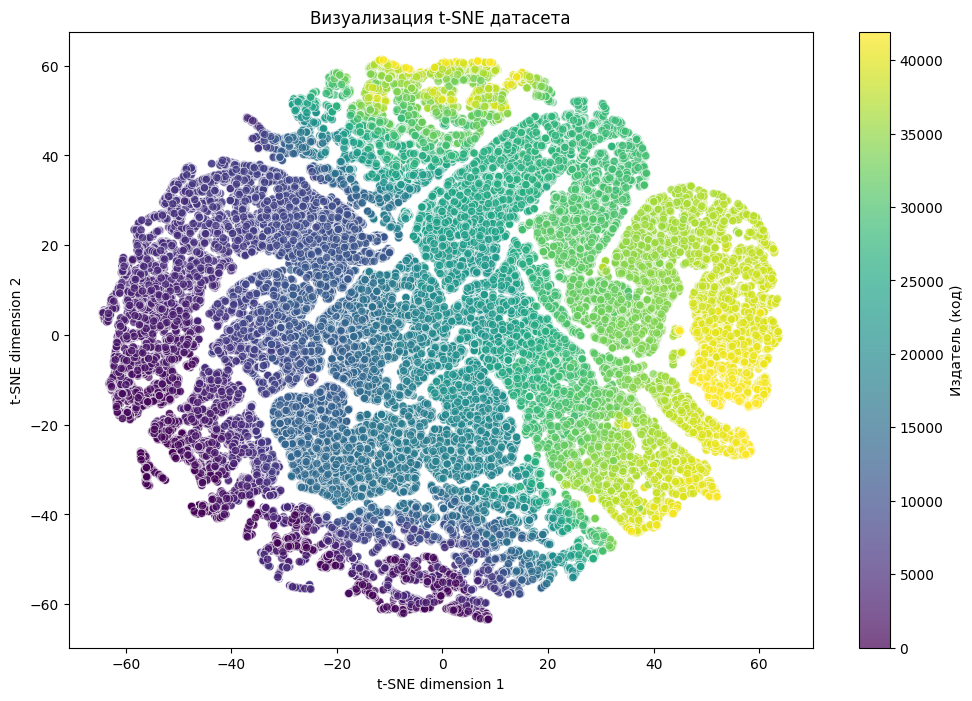

In [107]:
# Визуализация usd days_since_release developers_enc publishers_enc
# _col = ('usd', "Цена игры")
# _col = ('days_since_release', "Кол-во дней с выхода игры")
# _col = ('year', "Год")
# _col = ('developers_enc', "Разработчик (код)")
_col = ('publishers_enc', "Издатель (код)")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=data[_col[0]], 
                        cmap='viridis', alpha=0.7, edgecolors='w', linewidth=0.5)
plt.colorbar(scatter, label=_col[1])
plt.title('Визуализация t-SNE датасета')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')

from pathlib import Path
__path = Path(fr"output\tsne_s1_{_col[0]}.png")
plt.savefig(__path)

plt.show()

# Results

In [57]:
residuals = y_test - y_pred
diff = residuals.abs()

In [58]:
residuals.mean()

-0.16480336098886172

In [59]:
import scipy.stats as stats
stats.ttest_1samp(residuals, popmean=0)

TtestResult(statistic=-88.79390716506943, pvalue=0.0, df=692454)

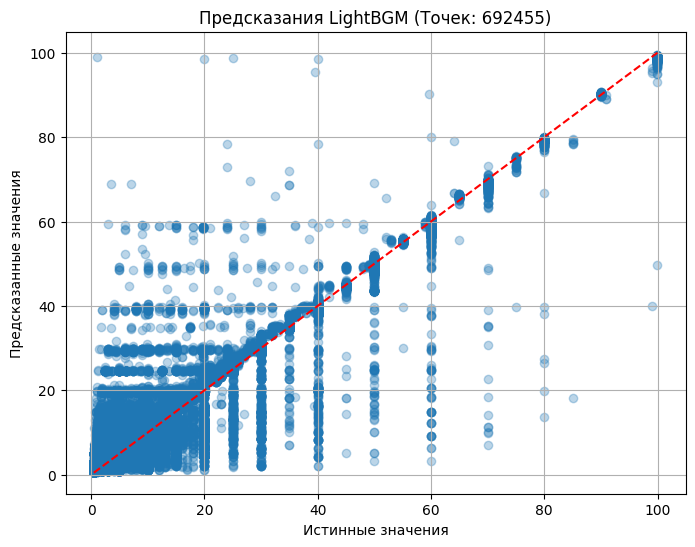

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.3)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Предсказания LightBGM (Точек: {len(y_pred)})')
plt.grid()
plt.show()

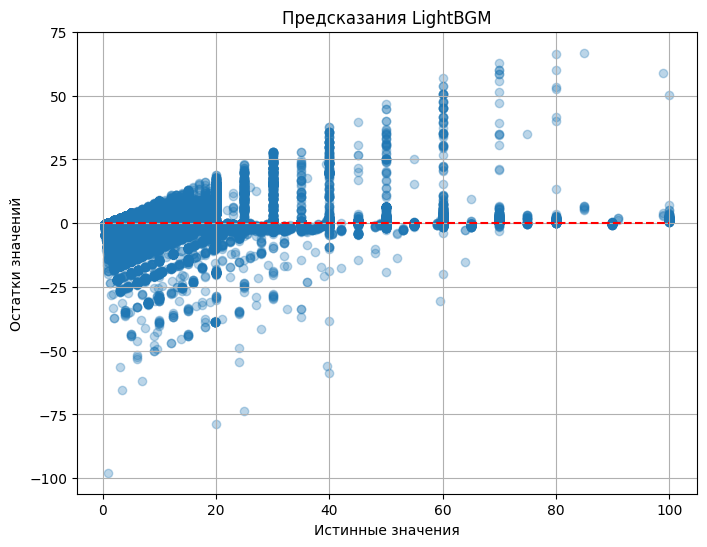

In [120]:
plt.figure(figsize=(8,6))
plt.scatter(y_true, residuals, alpha=0.3)
plt.plot([y_true.min(), y_true.max()], [0, 0], 'r--')
plt.xlabel('Истинные значения')
plt.ylabel('Остатки значений')
plt.title(f'Предсказания LightBGM')
plt.grid()
plt.show()

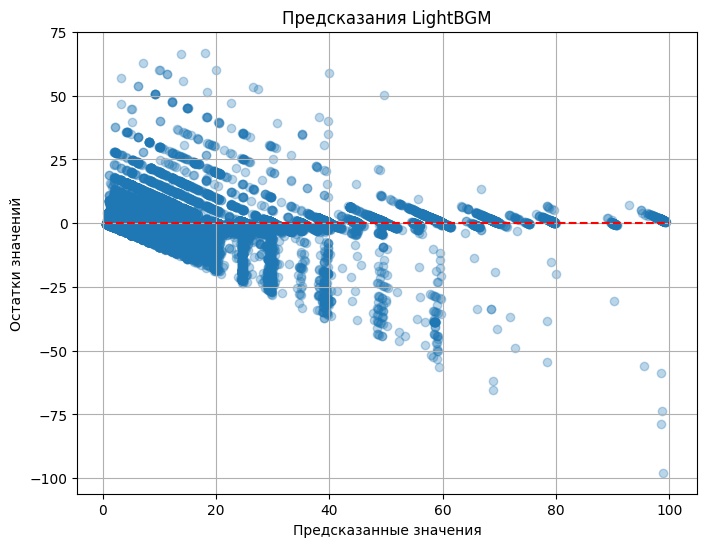

In [192]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.plot([y_true.min(), y_true.max()], [0, 0], 'r--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки значений')
plt.title(f'Предсказания LightBGM')
plt.grid()
plt.show()

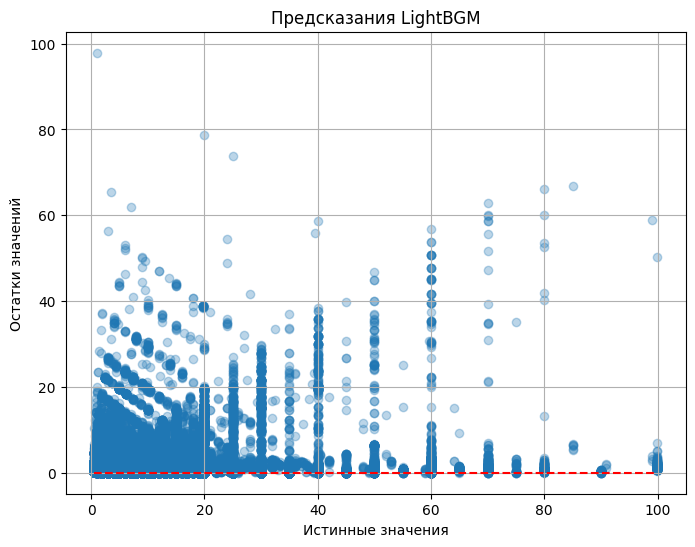

In [181]:
plt.figure(figsize=(8,6))
plt.scatter(y_true, diff, alpha=0.3)
plt.plot([y_true.min(), y_true.max()], [0, 0], 'r--')
plt.xlabel('Истинные значения')
plt.ylabel('Остатки значений')
plt.title(f'Предсказания LightBGM')
plt.grid()
plt.show()

In [182]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [183]:
r2 = r2_score(y_true, y_pred)
r2

0.9687904677067772

Text(0.5, 1.0, 'Гистограмма остатков')

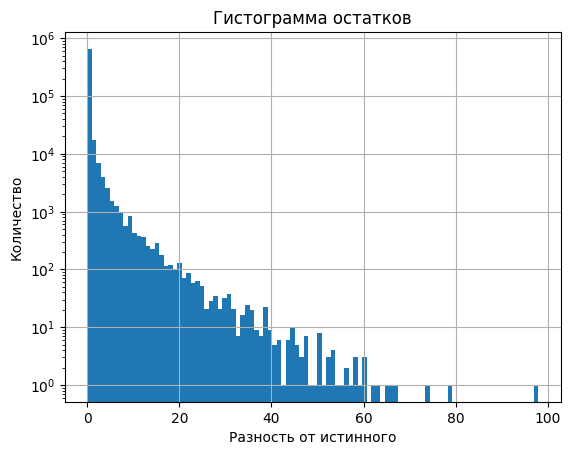

In [ ]:
diff.hist(bins=100, log=True)
plt.xlabel('Модуль остатка')
plt.ylabel('Количество')
plt.title('Гистограмма остатков')

In [185]:
import statsmodels.api as sm

<Figure size 600x600 with 0 Axes>

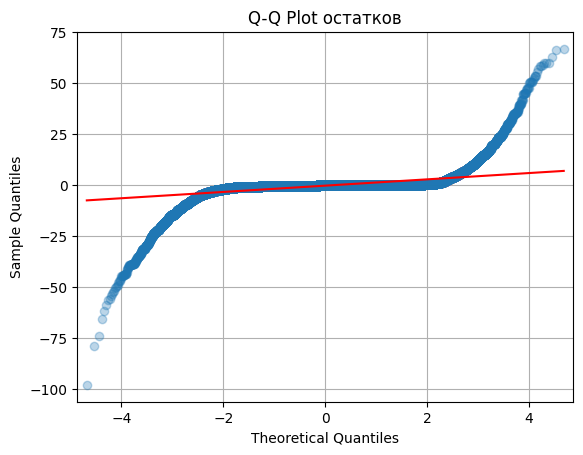

In [186]:
plt.figure(figsize=(6,6))
sm.qqplot(residuals, line='s', alpha=0.3)
plt.title('Q-Q Plot остатков')
plt.grid()
plt.show()

In [176]:
import scipy.stats as stats 

In [177]:
stats.normaltest(residuals), stats.wilcoxon(residuals), stats.shapiro(residuals)

d:\Program Files\GitHub\CompMath2\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 692455.
  res = hypotest_fun_out(*samples, **kwds)


(NormaltestResult(statistic=380254.79694168444, pvalue=0.0),
 WilcoxonResult(statistic=64712679218.0, pvalue=0.0),
 ShapiroResult(statistic=0.27923589426425455, pvalue=2.367332467712023e-219))

In [204]:
__mm = 0.5
(diff <= __mm).sum(), (diff > __mm).sum(), (diff > __mm).sum() / len(diff)

(598515, 93940, 0.1356622452000491)

In [219]:
tt = np.arange(0, 1.01, 0.01)
yy = []
for i in tt:
    yy.append((diff > i).sum() / len(diff))

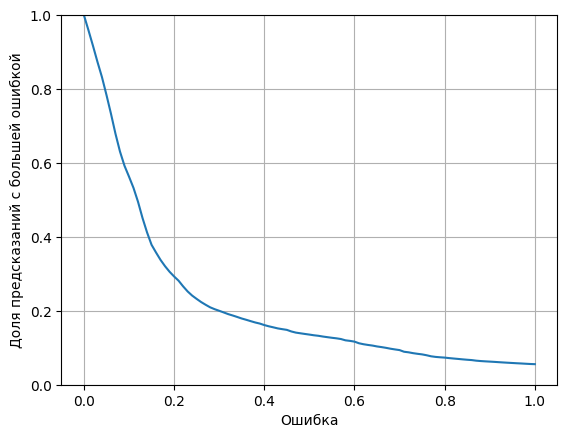

In [222]:
plt.plot(tt, yy)
plt.ylim([0,1])
plt.xlabel("Ошибка")
plt.ylabel("Доля предсказаний с большей ошибкой")
plt.grid()

In [178]:
title_enc: LabelEncoder = enc_dict['title']

In [179]:
y_pred

array([9.94619464, 9.91290635, 9.92957508, ..., 1.01877368, 1.07865691,
       1.04346462])

In [181]:
diff.max()

96.54012922615915

In [266]:
X_test.iloc[diff.argmax()-10:diff.argmax()+10]

,month_sin,month_cos,dow_sin,dow_cos,days_since_release,lag_1_price,lag_2_price,rolling_mean_3,rolling_mean_5,developers_enc,publishers_enc,genres_enc,supported_languages_enc
1491772,0.866025,0.5,-0.974928,-0.222521,1734,3.99,3.99,3.99,3.99,29417,26052,1433,12336
1491773,0.866025,0.5,0.000000,1.000000,1736,3.99,3.99,3.99,3.99,29417,26052,1433,12336
1491774,0.866025,0.5,0.974928,-0.222521,1738,3.99,3.99,3.99,3.99,29417,26052,1433,12336
1491775,0.866025,0.5,-0.433884,-0.900969,1740,3.99,3.99,3.99,3.99,29417,26052,1433,12336
1491776,0.866025,0.5,-0.781831,0.623490,1742,3.99,3.99,3.99,3.99,29417,26052,1433,12336
1491777,0.866025,0.5,0.781831,0.623490,1744,3.99,3.99,3.99,3.99,29417,26052,1433,12336
1491778,0.866025,0.5,0.433884,-0.900969,1746,3.99,3.99,3.99,3.99,29417,26052,1433,12336
1491779,0.866025,0.5,-0.974928,-0.222521,1748,3.99,3.99,3.99,3.99,29417,26052,1433,12336
1491780,0.866025,0.5,0.000000,1.000000,1750,3.99,3.99,3.99,3.99,29417,26052,1433,12336
1491817,0.866025,0.5,-0.974928,-0.222521,1731,99.99,99.99,99.99,99.99,44934,39727,1014,12796


In [258]:
y_pred[diff.argmax()-10:diff.argmax()+10]

array([ 4.11746515,  4.0611863 ,  4.07330769,  4.89393559,  4.10997184,
        4.02899198,  4.10387992,  4.11746515,  4.0611863 , 99.84606448,
       99.94423124,  3.22638258,  1.09024109, 20.6872112 , 16.46826819,
        1.00297083,  1.05133641,  1.03432295,  3.09245236,  3.05559094])

In [259]:
residuals[diff.argmax()-10:diff.argmax()+10]

1491772    -0.127465
1491773    -0.071186
1491774    -0.083308
1491775    -0.903936
1491776    -0.119972
1491777    -0.038992
1491778    -0.113880
1491779    -0.127465
1491780    -0.071186
1491817     0.143936
1491818   -98.954231
1491819    -2.236383
1491820    -0.100241
1491821   -19.697211
1491822   -15.478268
1491823    -0.012971
1491824    -0.061336
1491825    -0.044323
1491862    -0.102452
1491863    -0.065591
Name: usd, dtype: float64

In [260]:
max_title_enc = int(X_test.iloc[diff.argmax()]['title_enc'])
max_title_enc

KeyError: 'title_enc'

In [197]:
max_title = title_enc.inverse_transform([max_title_enc])[0]
max_title

'就这消消乐'

In [198]:
merged[merged['title'] == max_title][picked_cur][train_mask]

1491781     9.99
1491782     9.99
1491783     9.99
1491784     9.99
1491785    99.99
1491786    99.99
1491787    99.99
1491788    99.99
1491789    99.99
1491790    99.99
1491791    99.99
1491792     9.99
1491793     9.99
1491794     9.99
1491795     9.99
1491796     9.99
1491797     9.99
1491798     9.99
1491799    99.99
1491800    99.99
1491801    99.99
1491802    99.99
1491803    99.99
1491804    99.99
1491805    99.99
1491806    99.99
1491807    99.99
1491808    99.99
1491809    99.99
1491810    99.99
1491811    99.99
1491812    99.99
1491813    99.99
1491814    99.99
1491815    99.99
1491816    99.99
Name: usd, dtype: float64

In [261]:
mask_border = df_test['date_acquired'] == test_start_date

In [262]:
diff[mask_border]

36         0.018476
81         0.070244
126        0.078614
171        0.070244
216        0.287314
             ...   
3463075    0.100536
3463098    0.066151
3463121    0.046298
3463144    0.038466
3463167    0.046298
Name: usd, Length: 76949, dtype: float64

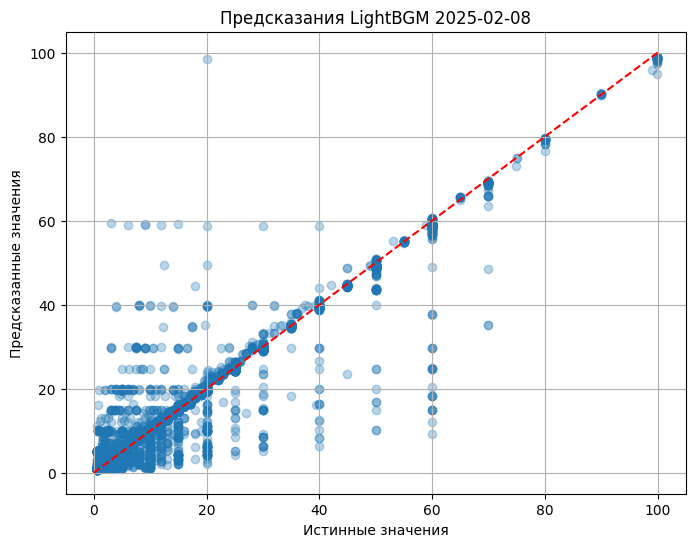

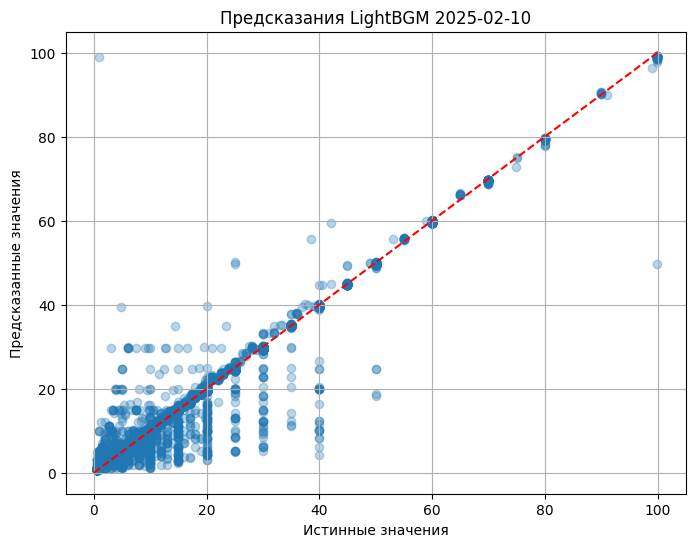

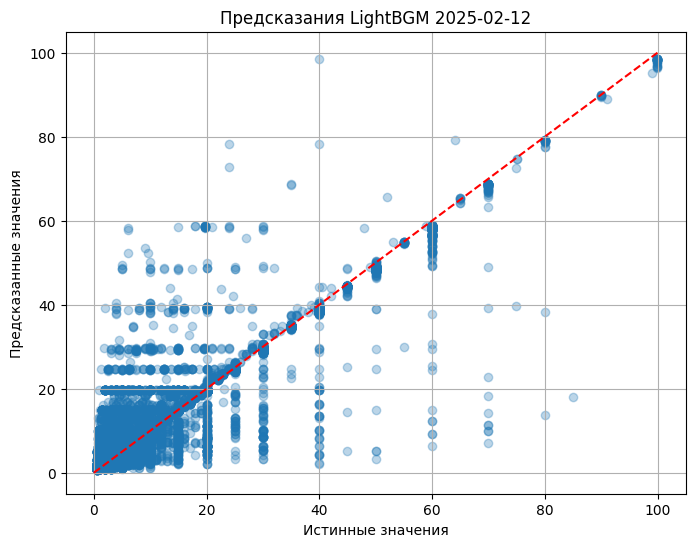

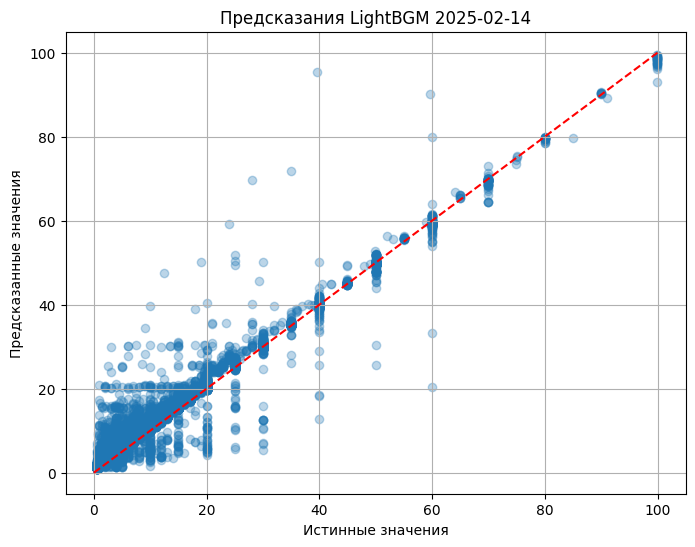

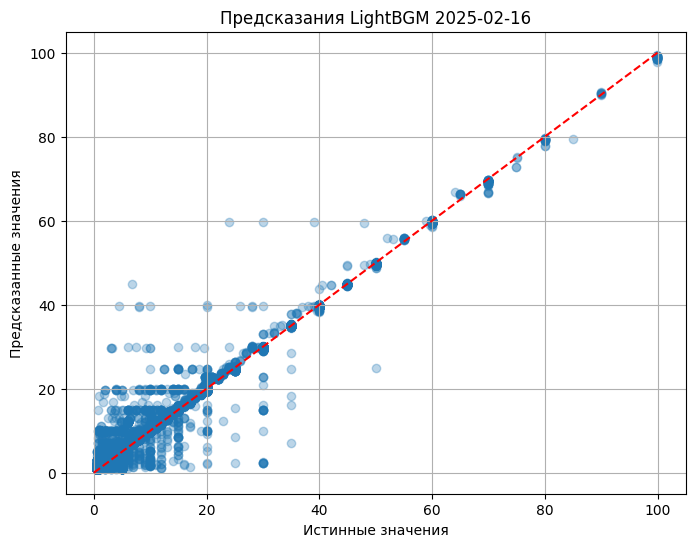

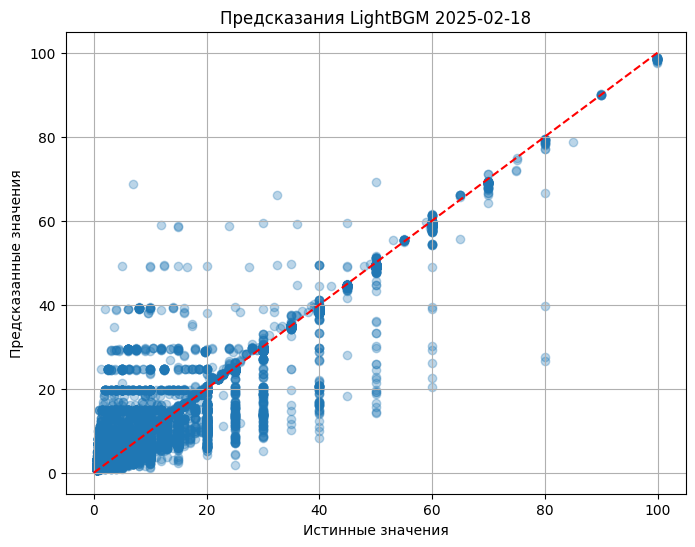

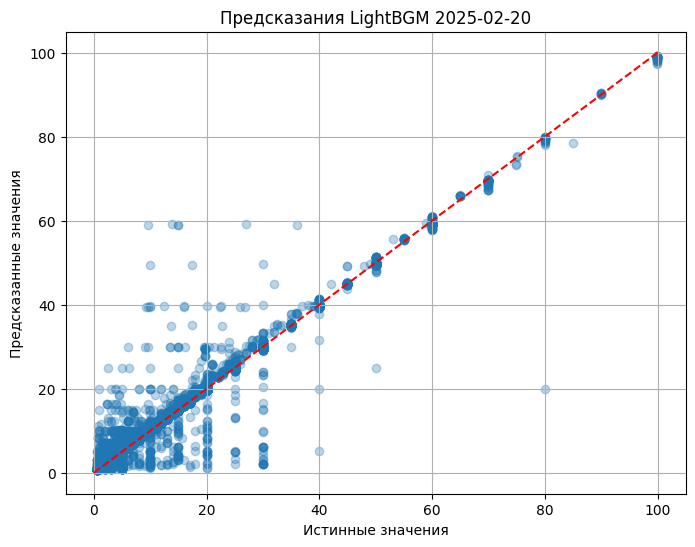

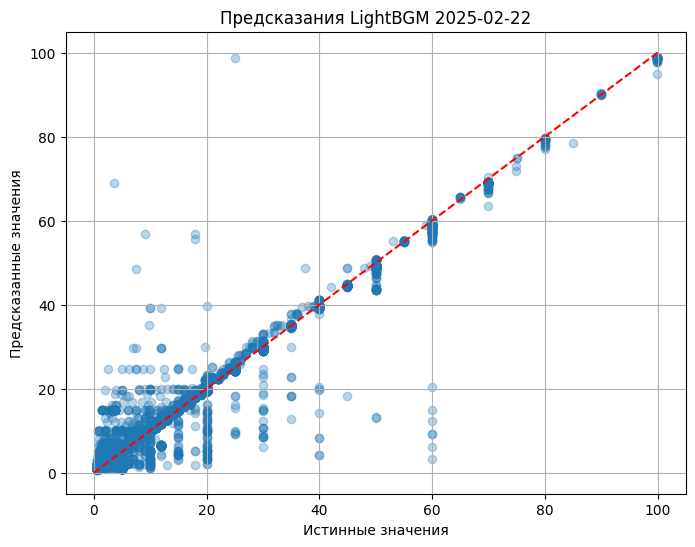

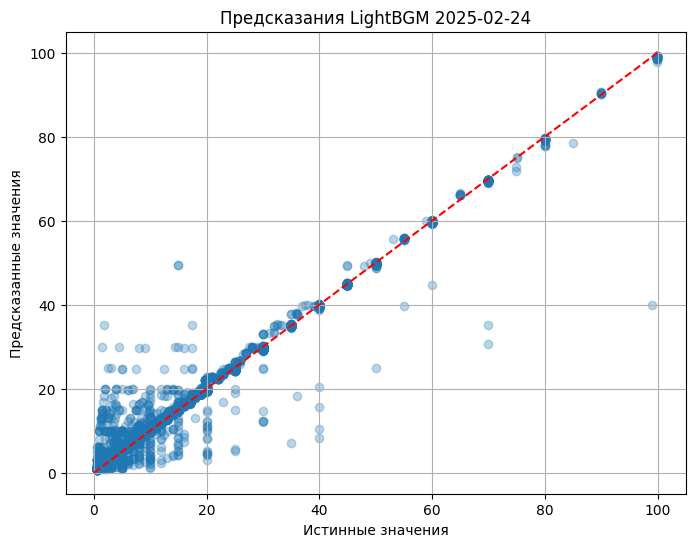

In [61]:
for _date in da[da >= test_start_date]:
    mask_border = df_test['date_acquired'] == _date

    plt.figure(figsize=(8,6))
    plt.scatter(y_true[mask_border], y_pred[mask_border], alpha=0.3)
    plt.plot([0, y_true.max()], [0, y_true.max()], 'r--')
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные значения')
    plt.title(f'Предсказания LightBGM {_date.astype('datetime64[D]')}')
    plt.grid()
    plt.show()

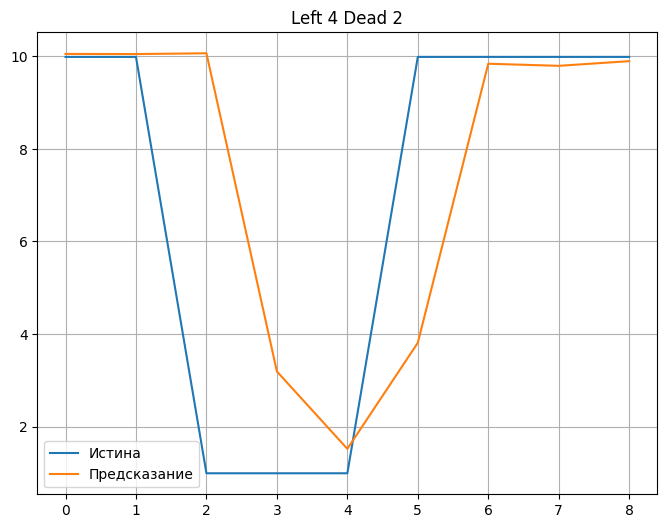

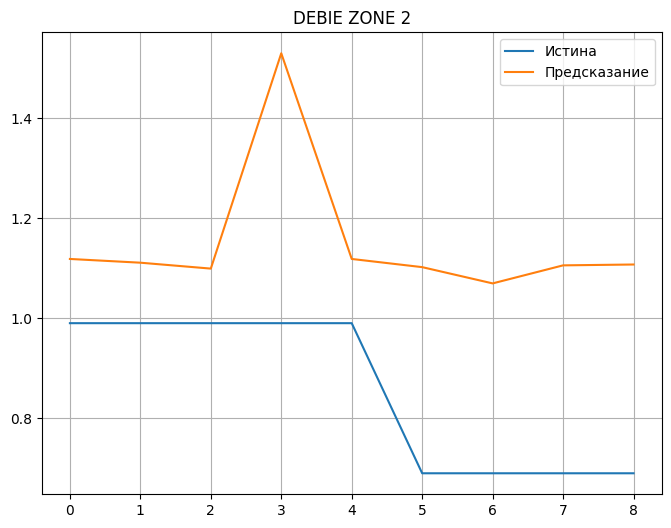

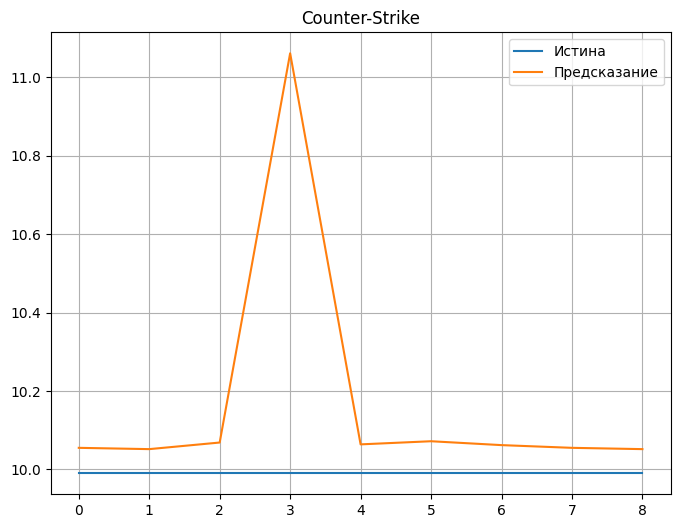

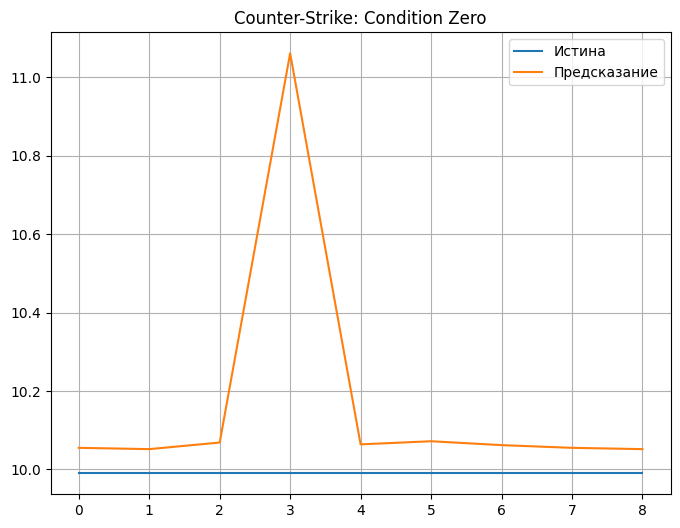

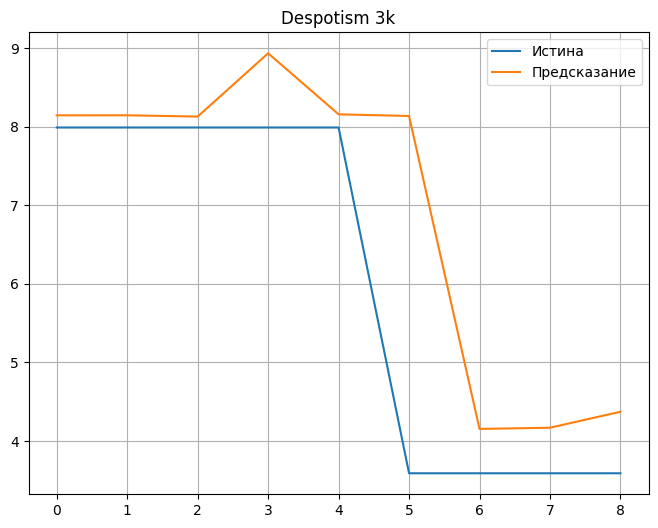

In [ ]:
LIST = [
    # (1145360, "Hades"), 
    # (1196590, "Resident Evil Village"), 
    # (250900, "The Binding of Isaac: Rebirth"),
    # (2114740, "Blasphemous 2"),
    # (526870, "Satisfactory"),
    (550, "Left 4 Dead 2"),
    (3416630,"DEBIE ZONE 2"),
    (10,"Counter-Strike"),
    (100,"Counter-Strike: Condition Zero"),
    (699920, "Despotism 3k")
]

for GAME_ID, NAME in LIST:
    mask = df_test['gameid'] == GAME_ID

    l = len(y_true[mask])

    plt.figure(figsize=(8,6))
    plt.title(NAME)
    plt.grid()
    plt.plot(range(l), y_true[mask])
    plt.plot(range(l), y_pred[mask])
    plt.legend(["Истина", "Предсказание"])

In [104]:
MMM = df_test['rolling_mean_5'] > df_test['usd']
df_test[MMM].sample(n=10)

,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,date_acquired,days_since_release,...,dow_cos,lag_1_price,lag_2_price,rolling_mean_3,rolling_mean_5,title_enc,developers_enc,publishers_enc,genres_enc,supported_languages_enc
2402393,2025700,Fragile Feelings,['ebi-hime'],['ebi-hime'],['Casual'],['English'],2023,7.79,2025-02-22,499,...,-0.222521,7.79,7.79,9.523333,10.91,23991,44125,39005,1075,12336
1685358,1442450,Monsters Domain,['G-DEVS.com'],"['G-DEVS.com', 'CreativeForge Games']","['Action', 'Indie', 'RPG', 'Strategy']","['English', 'French', 'Italian', 'German', 'Sp...",2024,3.99,2025-02-14,315,...,-0.900969,3.99,3.99,3.990000,10.39,40673,14407,12911,458,5216
1098713,1013870,Leanna's Slice of Life,['Acerola'],['Kagura Games'],"['Indie', 'RPG']","['English', 'Simplified Chinese']",2019,5.99,2025-02-20,2177,...,-0.900969,5.99,5.99,8.990000,11.39,35408,1461,18119,1208,11346
297439,421810,OH! RPG!,['RosePortal Games'],['Aldorlea Games'],"['Adventure', 'Casual', 'Indie', 'RPG', 'Strat...",['English'],2015,0.89,2025-02-24,3363,...,1.000000,0.89,0.89,0.890000,1.73,43943,32708,2152,597,12336
630054,674380,Delude - Succubus Prison,['Halissoni'],['Conglomerate 5'],"['Adventure', 'Casual', 'Indie', 'RPG', 'Simul...",['English'],2017,0.49,2025-02-22,2759,...,-0.222521,0.49,0.49,0.656667,0.79,16388,16540,7399,593,12336
2990180,2613830,Install Fee Tycoon,['Moonstruck'],['Moonstruck'],['Casual'],['English'],2023,0.49,2025-02-10,489,...,1.000000,0.49,0.49,0.490000,0.69,32024,25573,22652,1075,12336
2235390,1878840,Luna: Supernatural Hunter,['SharedWill Studio'],['SharedWill Studio'],"['Action', 'Indie']",['English'],2022,1.19,2025-02-14,1088,...,-0.900969,2.99,2.99,2.990000,2.99,37218,34299,30396,493,12336
3344036,3064550,Twelve Sticks,['Beshbarmak games'],[' Beshbarmak games\t'],"['Indie', 'Massively Multiplayer', 'Early Acce...","['English', 'French', 'German', 'Spanish - Spa...",2024,3.49,2025-02-22,150,...,-0.222521,4.99,4.99,4.990000,4.99,68318,4775,291,1176,1815
709089,728420,Rogue Quest: The Vault of the Lost Tyrant,['ExperaGameStudio'],['Eli Daddio'],"['Adventure', 'Indie']","['English', 'Italian']",2017,0.99,2025-02-20,2675,...,-0.900969,0.99,4.99,3.656667,4.19,52117,12689,10683,727,8543
668724,699920,Despotism 3k,['Konfa Games'],['Konfa Games'],"['Indie', 'Simulation', 'Strategy']","['English', 'Russian', 'German', 'Simplified C...",2018,3.59,2025-02-24,2300,...,1.000000,3.59,3.59,3.590000,5.35,16716,21058,18720,1244,10201


In [91]:
MMM.any()

True